# Method Comparison Benchmark

This notebook demonstrates how to use DROs for benchmarking and comparing different fitting methods.

## Learning Objectives

- Compare LLS, WLLS, and IWLLS fitting methods
- Understand bias/variance trade-offs
- Use Monte Carlo simulations for method validation
- Interpret performance across SNR levels

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qmri.diffusion import adc
from qmri.dro import dwi

## 1. ADC Fitting Methods

Three methods are available:

1. **LLS** (Linear Least Squares): Fast, but suboptimal at low SNR
2. **WLLS** (Weighted LLS): Uses predicted signals as weights
3. **IWLLS** (Iterative WLLS): Iteratively refines weights (recommended)

In [2]:
# Single comparison at moderate SNR
true_adc = 1.0e-3
phantom = dwi.generate(adc=true_adc, snr=30, seed=42)

methods = ["lls", "wlls", "iwlls"]
print(f"True ADC: {true_adc:.2e} mm²/s\n")

for method in methods:
    result = adc.fit(phantom.signal, phantom.b_values, method=method)
    error = 100 * (result.adc - true_adc) / true_adc
    print(
        f"{method.upper():6} - ADC: {result.adc:.3e}  Error: {error:+5.1f}%  R²: {result.r_squared:.4f}"
    )

True ADC: 1.00e-03 mm²/s

LLS    - ADC: 9.356e-04  Error:  -6.4%  R²: 0.9964
WLLS   - ADC: 9.819e-04  Error:  -1.8%  R²: 0.9981
IWLLS  - ADC: 9.848e-04  Error:  -1.5%  R²: 0.9981


## 2. Monte Carlo Method Comparison

Let's run many simulations to compare bias and variance of each method.

In [3]:
def monte_carlo_comparison(true_adc, snr, n_simulations=500):
    """Run Monte Carlo simulations comparing fitting methods."""
    results = {method: [] for method in methods}

    for seed in range(n_simulations):
        phantom = dwi.generate(adc=true_adc, snr=snr, seed=seed)
        for method in methods:
            result = adc.fit(phantom.signal, phantom.b_values, method=method)
            results[method].append(result.adc)

    # Calculate statistics
    stats = {}
    for method in methods:
        values = np.array(results[method])
        stats[method] = {
            "mean": np.mean(values),
            "std": np.std(values),
            "bias": np.mean(values) - true_adc,
            "bias_pct": 100 * (np.mean(values) - true_adc) / true_adc,
            "cv": 100 * np.std(values) / np.mean(values),  # Coefficient of variation
            "values": values,
        }

    return stats

In [4]:
# Run Monte Carlo at different SNR levels
snr_levels = [10, 20, 30, 50, 100]
true_adc = 1.0e-3

all_stats = {}
for snr in snr_levels:
    print(f"Running SNR = {snr}...")
    all_stats[snr] = monte_carlo_comparison(true_adc, snr)

print("Done!")

Running SNR = 10...
Running SNR = 20...
Running SNR = 30...
Running SNR = 50...
Running SNR = 100...
Done!


In [5]:
# Print summary table
print(f"True ADC: {true_adc:.2e} mm²/s")
print("=" * 80)
print(f"{'SNR':>5} {'Method':>8} {'Mean ADC':>12} {'Bias (%)':>10} {'CV (%)':>10}")
print("-" * 80)

for snr in snr_levels:
    for method in methods:
        s = all_stats[snr][method]
        print(
            f"{snr:>5} {method.upper():>8} {s['mean']:.3e} {s['bias_pct']:>+10.1f} {s['cv']:>10.1f}"
        )
    print("-" * 80)

True ADC: 1.00e-03 mm²/s
  SNR   Method     Mean ADC   Bias (%)     CV (%)
--------------------------------------------------------------------------------
   10      LLS 1.007e-03       +0.7       22.4
   10     WLLS 9.794e-04       -2.1       11.7
   10    IWLLS 1.001e-03       +0.1       11.8
--------------------------------------------------------------------------------
   20      LLS 1.003e-03       +0.3       10.6
   20     WLLS 9.947e-04       -0.5        5.8
   20    IWLLS 1.000e-03       +0.0        5.8
--------------------------------------------------------------------------------
   30      LLS 1.002e-03       +0.2        7.0
   30     WLLS 9.976e-04       -0.2        3.9
   30    IWLLS 1.000e-03       +0.0        3.9
--------------------------------------------------------------------------------
   50      LLS 1.001e-03       +0.1        4.1
   50     WLLS 9.991e-04       -0.1        2.3
   50    IWLLS 1.000e-03       -0.0        2.3
-------------------------------------

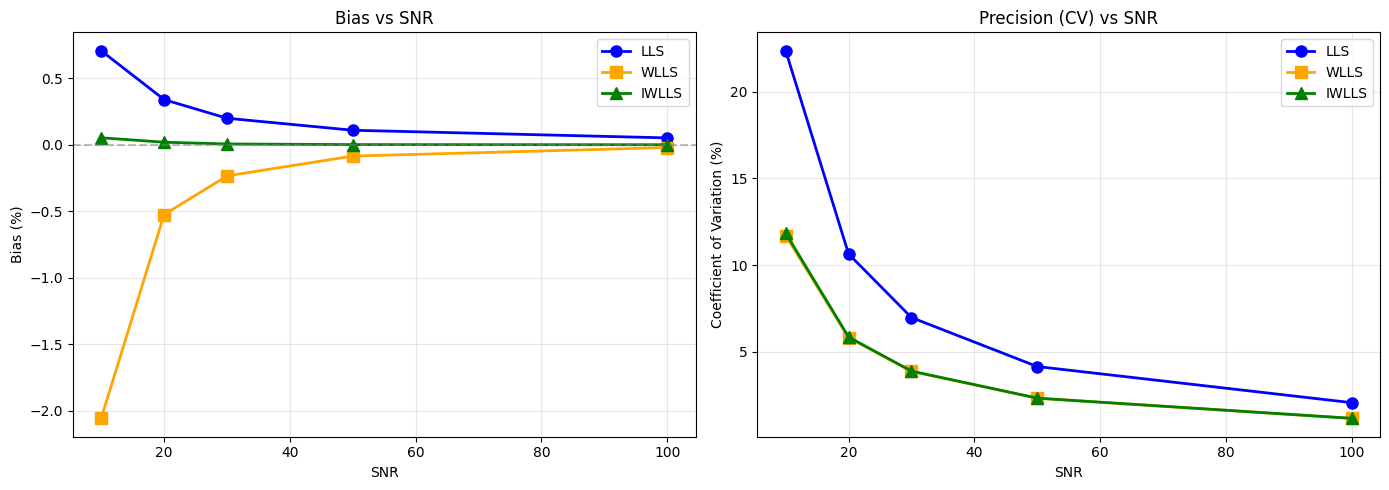

In [6]:
# Plot bias and variance vs SNR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"lls": "blue", "wlls": "orange", "iwlls": "green"}
markers = {"lls": "o", "wlls": "s", "iwlls": "^"}

# Bias plot
ax = axes[0]
for method in methods:
    bias = [all_stats[snr][method]["bias_pct"] for snr in snr_levels]
    ax.plot(
        snr_levels,
        bias,
        f"-{markers[method]}",
        color=colors[method],
        linewidth=2,
        markersize=8,
        label=method.upper(),
    )

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("SNR")
ax.set_ylabel("Bias (%)")
ax.set_title("Bias vs SNR")
ax.legend()
ax.grid(True, alpha=0.3)

# CV (precision) plot
ax = axes[1]
for method in methods:
    cv = [all_stats[snr][method]["cv"] for snr in snr_levels]
    ax.plot(
        snr_levels,
        cv,
        f"-{markers[method]}",
        color=colors[method],
        linewidth=2,
        markersize=8,
        label=method.upper(),
    )

ax.set_xlabel("SNR")
ax.set_ylabel("Coefficient of Variation (%)")
ax.set_title("Precision (CV) vs SNR")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

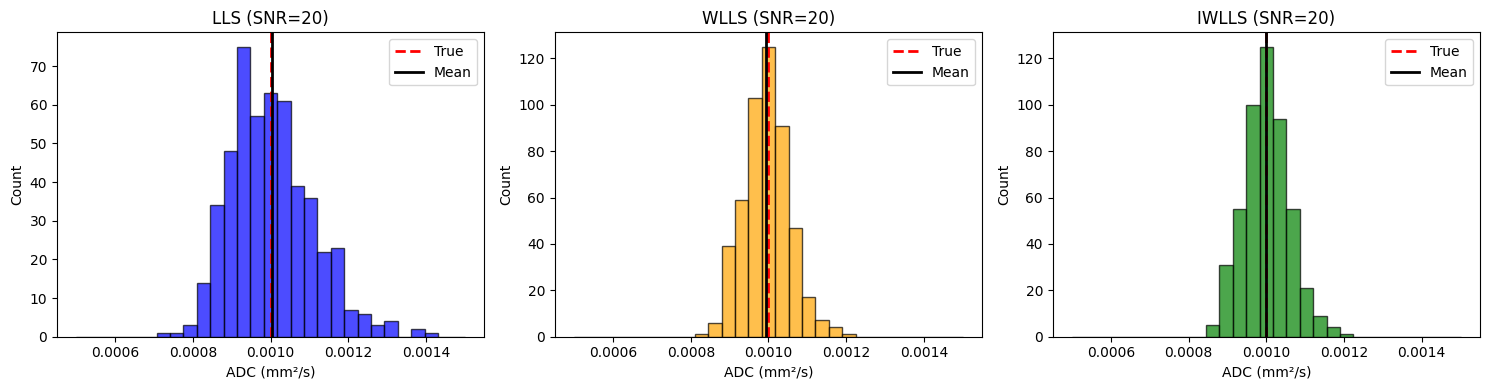

In [7]:
# Distribution comparison at low SNR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

snr = 20  # Low SNR case
bins = np.linspace(0.5e-3, 1.5e-3, 30)

for ax, method in zip(axes, methods):
    values = all_stats[snr][method]["values"]
    ax.hist(values, bins=bins, edgecolor="black", alpha=0.7, color=colors[method])
    ax.axvline(true_adc, color="red", linestyle="--", linewidth=2, label="True")
    ax.axvline(np.mean(values), color="black", linestyle="-", linewidth=2, label="Mean")
    ax.set_xlabel("ADC (mm²/s)")
    ax.set_ylabel("Count")
    ax.set_title(f"{method.upper()} (SNR={snr})")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Effect of b-value Selection

In [8]:
# Compare different b-value protocols
b_value_protocols = {
    "Clinical 3pt": (0, 500, 1000),
    "Clinical 4pt": (0, 500, 1000, 2000),
    "Extended": (0, 200, 400, 600, 800, 1000),
    "High-b": (0, 500, 1000, 1500, 2000, 2500),
}


def protocol_comparison(true_adc, snr, n_simulations=200):
    results = {}
    for name, b_values in b_value_protocols.items():
        adc_values = []
        for seed in range(n_simulations):
            phantom = dwi.generate(adc=true_adc, b_values=b_values, snr=snr, seed=seed)
            result = adc.fit(phantom.signal, phantom.b_values, method="iwlls")
            adc_values.append(result.adc)

        values = np.array(adc_values)
        results[name] = {
            "bias_pct": 100 * (np.mean(values) - true_adc) / true_adc,
            "cv": 100 * np.std(values) / np.mean(values),
        }
    return results

In [9]:
protocol_results = protocol_comparison(true_adc=1.0e-3, snr=30)

print("Protocol Comparison (IWLLS, SNR=30, ADC=1.0e-3)")
print("=" * 50)
print(f"{'Protocol':<15} {'Bias (%)':>10} {'CV (%)':>10}")
print("-" * 50)
for name, stats in protocol_results.items():
    print(f"{name:<15} {stats['bias_pct']:>+10.2f} {stats['cv']:>10.2f}")

Protocol Comparison (IWLLS, SNR=30, ADC=1.0e-3)
Protocol          Bias (%)     CV (%)
--------------------------------------------------
Clinical 3pt         -0.39       5.12
Clinical 4pt         +0.01       3.70
Extended             -0.13       4.21
High-b               -0.03       2.25


## 4. Calibration Phantom Benchmark

In [10]:
# Use the built-in calibration phantom
cal_phantom = dwi.generate_calibration_phantom(snr=50, seed=42)
true_values = cal_phantom.ground_truth["adc"].value

print("Calibration Phantom Results:")
print("=" * 70)
print(f"{'True ADC':<12} {'LLS':>12} {'WLLS':>12} {'IWLLS':>12}")
print("-" * 70)

for i, true_val in enumerate(true_values):
    row = f"{true_val:.2e}"
    for method in methods:
        result = adc.fit(cal_phantom.signal[i], cal_phantom.b_values, method=method)
        row += f" {result.adc:>12.2e}"
    print(row)

Calibration Phantom Results:
True ADC              LLS         WLLS        IWLLS
----------------------------------------------------------------------
3.00e-04     3.10e-04     3.12e-04     3.12e-04
7.00e-04     7.07e-04     6.97e-04     6.97e-04
1.00e-03     9.92e-04     9.95e-04     9.95e-04
1.50e-03     1.47e-03     1.45e-03     1.45e-03
2.00e-03     1.99e-03     2.00e-03     2.00e-03
3.00e-03     2.86e-03     2.98e-03     2.98e-03


## Summary

Key findings:

1. **IWLLS is recommended**: Best balance of bias and variance
2. **LLS has positive bias at low SNR**: Due to log-transform of noisy data
3. **More b-values help**: But with diminishing returns
4. **High b-values improve precision**: But may introduce other artifacts
5. **Monte Carlo is essential**: Single fits don't reveal method performance